In [1]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
data=load_breast_cancer()
X=pd.DataFrame(
    data.data,
    columns=data.feature_names
)
y=data.target
print(X.head())
print(X.shape)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [2]:
print(data.target_names)


['malignant' 'benign']


In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [4]:
from sklearn.naive_bayes import GaussianNB
model=GaussianNB()
model.fit(X_train,y_train)


,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[170.,285.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.37,0.63]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,0.0003051
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,30
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 30)","[[ 17.38, 21.58,114.83,..., 0.18, 0.33, 0.09], [ 12.09, 17.86, 77.68,..., 0.07, 0.27, 0.08]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 30)","[[ 9.96, 15.41,464.88,..., 0. , 0.01, 0. ], [ 3.11, 16.54,135.9 ,..., 0. , 0. , 0. ]]"


In [5]:
y_pred=model.predict(X_test)


In [6]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual  Predicted
0       0          0
1       1          1
2       0          0
3       1          1
4       0          0
5       1          1
6       1          1
7       0          0
8       0          0
9       0          0


In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Accuracy:", accuracy)

Accuracy: 0.9385964912280702


In [8]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

print(classification_report(
    y_test,
    y_pred
))

print(confusion_matrix(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114

[[38  4]
 [ 3 69]]


In [9]:
print(model.class_prior_)


[0.37362637 0.62637363]


In [10]:
print(model.theta_)

[[1.73812353e+01 2.15798824e+01 1.14830647e+02 9.66820000e+02
  1.02993941e-01 1.46144824e-01 1.62362882e-01 8.76072353e-02
  1.93630588e-01 6.28292941e-02 5.94710588e-01 1.20105000e+00
  4.23124118e+00 6.98808824e+01 6.79774118e-03 3.24939824e-02
  4.31357059e-02 1.50777235e-02 2.09235235e-02 4.01020588e-03
  2.09670588e+01 2.92767647e+01 1.40258176e+02 1.39677118e+03
  1.44847588e-01 3.78881824e-01 4.63242824e-01 1.82847412e-01
  3.26841176e-01 9.17371176e-02]
 [1.20904281e+01 1.78560351e+01 7.76751228e+01 4.58690526e+02
  9.20954737e-02 7.86516842e-02 4.55483218e-02 2.49237474e-02
  1.72856140e-01 6.28141053e-02 2.82215439e-01 1.22927474e+00
  1.98227825e+00 2.09689649e+01 7.25420351e-03 2.13887860e-02
  2.62396828e-02 9.64176491e-03 2.06925228e-02 3.67027754e-03
  1.33201333e+01 2.34823509e+01 8.65635789e+01 5.54231579e+02
  1.24861649e-01 1.80033649e-01 1.65234375e-01 7.27803895e-02
  2.69405965e-01 7.92964561e-02]]


New Patient Data
       ↓
For Class 0:
Calculate likelihood of every feature
       ↓
Multiply/combine with prior
       ↓
Calculate class score

For Class 1:
Calculate likelihood of every feature
       ↓
Multiply/combine with prior
       ↓
Calculate class score
       ↓
Choose the larger probability

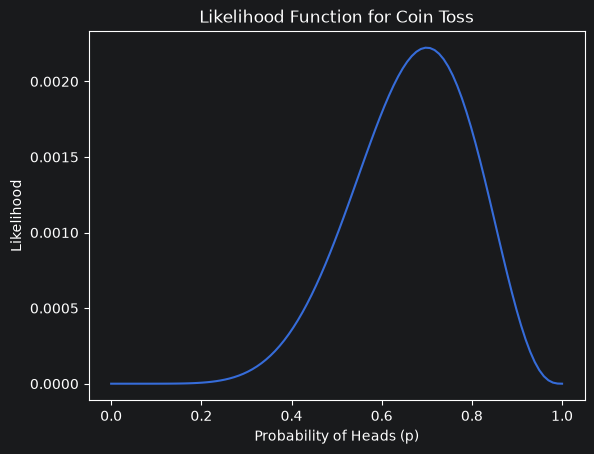

In [11]:
import numpy as np

# Coin toss: 7 heads, 3 tails
heads, tails = 7, 3

def likelihood(p):
    return (p**heads) * ((1-p)**tails)

p_values = np.linspace(0, 1, 100)
likelihoods = [likelihood(p) for p in p_values]

import matplotlib.pyplot as plt
plt.plot(p_values, likelihoods)
plt.xlabel("Probability of Heads (p)")
plt.ylabel("Likelihood")
plt.title("Likelihood Function for Coin Toss")
plt.show()


In [12]:
import numpy as np

fail = np.array([1, 2, 3])
passed = np.array([7, 8, 9])

print("Fail Mean:", np.mean(fail))
print("Fail Variance:", np.var(fail))

print("Pass Mean:", np.mean(passed))
print("Pass Variance:", np.var(passed))

Fail Mean: 2.0
Fail Variance: 0.6666666666666666
Pass Mean: 8.0
Pass Variance: 0.6666666666666666


In [13]:
def gaussian_pdf(x, mean, variance):

    numerator = np.exp(
        -((x - mean) ** 2) / (2 * variance)
    )

    denominator = np.sqrt(
        2 * np.pi * variance
    )

    return numerator / denominator

In [14]:
x = 6

fail_likelihood = gaussian_pdf(
    x,
    np.mean(fail),
    np.var(fail)
)

pass_likelihood = gaussian_pdf(
    x,
    np.mean(passed),
    np.var(passed)
)

print("P(x=6 | Fail):", fail_likelihood)
print("P(x=6 | Pass):", pass_likelihood)

P(x=6 | Fail): 3.0020775895011144e-06
P(x=6 | Pass): 0.02432608666482073
